<a href="https://colab.research.google.com/github/Naren219/ai-stuff/blob/main/Neural_Weight_Pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# a very simple amateur experiment on neural nets
by naren manikandan 🐯

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
torch.set_default_device('cuda')

In [ ]:
def get_mlp_out(x, w1, w2):
  y1 = F.relu(x @ w1)
  return y1 @ w2

batch_mlp = torch.vmap(get_mlp_out)

In [ ]:
class XLinear(nn.Module):
  def __init__(self, concat_features=17):
    super().__init__()

    hidden_dims = [256, 512, 512, 256, 128]
    layers = []
    in_dim = concat_features
    for hidden_dim in hidden_dims:
      layers.append(nn.Linear(in_dim, hidden_dim))
      in_dim = hidden_dim + concat_features

    self.layers = nn.ModuleList(layers)
    self.out = nn.Linear(in_dim, 1)

  def forward(self, x):
    out = x
    for layer in self.layers:
      out = F.relu(layer(out))
      out = torch.cat((out, x), dim=1)

    return self.out(out)


In [ ]:
model_x = XLinear()
print("param count:", sum(p.numel() for p in model_x.parameters()))

param count: 587154


In [ ]:
class ResBlock(nn.Module):
  def __init__(self, in_dim, out_dim):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(in_dim, out_dim),
      nn.BatchNorm1d(out_dim),
      nn.ReLU(),
      nn.Linear(out_dim, out_dim),
      nn.BatchNorm1d(out_dim),
    )
    self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

  def forward(self, x):
    return F.relu(self.net(x) + self.skip(x))

class ResLinear(nn.Module):
  def __init__(self, concat_features = 17, hidden_dim = 256, out_dim = 1):
    super().__init__()
    self.l1 = nn.Linear(concat_features, hidden_dim)
    self.res2 = ResBlock(hidden_dim, hidden_dim)
    self.res3 = ResBlock(hidden_dim, hidden_dim)
    self.res4 = ResBlock(hidden_dim, hidden_dim)
    self.l5 = nn.Linear(hidden_dim, out_dim)

  def forward(self, x):
    x = F.relu((self.l1(x)))
    x = self.res2(x)
    x = self.res3(x)
    x = self.res4(x)
    return self.l5(x)

In [ ]:
model_res = ResLinear()
print("param count:", sum(p.numel() for p in model_res.parameters()))

param count: 402689


In [ ]:
batch_size = 1024

def get_data():
  x_raw = torch.randn(batch_size, 2)
  w1 = torch.randn(batch_size, 2, 5)
  w2 = torch.randn(batch_size, 5, 1)
  y = batch_mlp(x_raw, w1, w2)
  x = torch.cat((x_raw, w1.flatten(1), w2.flatten(1)), 1)
  return x, y

In [ ]:
x, y = get_data()
x.shape, y.shape

(torch.Size([1024, 17]), torch.Size([1024, 1]))

In [ ]:
def train(model, data_fn, lr=0.01, epochs=50000):
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  loss = nn.MSELoss()
  avgs = []
  avg = None

  t = tqdm(range(epochs), mininterval=1.0)
  for i in t:
    x, y = data_fn()
    optimizer.zero_grad()
    y_pred = model(x)
    output = loss(y_pred, y)
    output.backward()
    optimizer.step()

    if avg is None:
        avg = output.item()
    else:
        avg = 0.99 * avg + 0.01 * output.item()

    avgs.append(avg)

    t.set_description(f"loss: {avg:.4f}")

  return avgs

In [ ]:
avgs_xlin = train(model_x, lambda: get_data())
avgs_res = train(model_res, lambda: get_data())

loss: 0.0188: 100%|██████████| 50000/50000 [05:40<00:00, 147.06it/s]


Below are the results. pretty cool! residual network with the relu nonlinearity in between each residual block is the best.

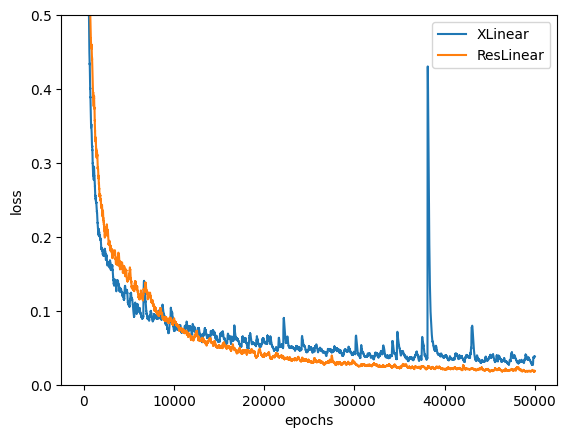

In [ ]:
plt.plot(avgs_xlin, label="XLinear")
plt.plot(avgs_res, label="ResLinear")
plt.ylim(0, 0.5)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show();

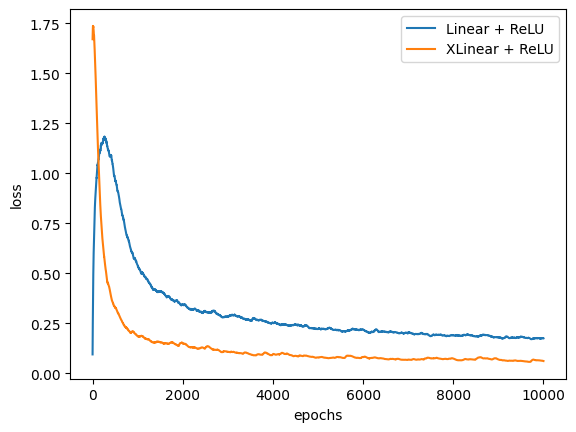

## part 2:

In [ ]:
batch_size = 1024

In [ ]:
def get_simple_data(num_unknowns, num_pairs):
  w = torch.randn(batch_size, num_unknowns, 1)
  pairs = []
  for i in range(num_pairs):
    x = torch.randn(batch_size, num_unknowns)
    y = torch.bmm(x.unsqueeze(1), w).squeeze(1)
    pairs.append(x)
    pairs.append(y)

  inp = torch.cat(tuple(pairs), dim=1)
  out = w.flatten(1)

  return inp, out

x, y = get_simple_data(num_unknowns=3, num_pairs=5)
x.shape, y.shape

(torch.Size([1024, 20]), torch.Size([1024, 3]))

In [ ]:
model_th = ResLinear(concat_features = 12, out_dim = 3)
model_five = ResLinear(concat_features = 20, out_dim = 3)

In [ ]:
avgs_three = train(model_th, lambda: get_simple_data(num_unknowns=3, num_pairs=3), lr=1e-3, epochs=20000)
avgs_five = train(model_five, lambda: get_simple_data(num_unknowns=3, num_pairs=5), lr=1e-3, epochs=20000)

loss: 0.0681: 100%|██████████| 20000/20000 [02:17<00:00, 145.53it/s]


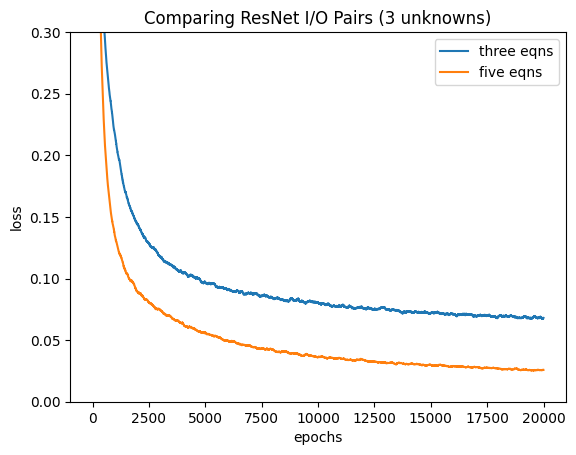

In [ ]:
plt.plot(avgs_three, label="three eqns")
plt.plot(avgs_five, label="five eqns")
plt.ylim(0, 0.3)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Comparing ResNet I/O Pairs (3 unknowns)")
plt.legend()
plt.show();

In [ ]:
def get_data_v2(num_pairs):
  """
  30 pairs for 15 unknowns (2*5+5*1).
  """
  w1 = torch.randn(batch_size, 2, 5)
  w2 = torch.randn(batch_size, 5, 1)
  pairs = []
  for i in range(num_pairs):
    x = torch.randn(batch_size, 2)
    y = batch_mlp(x, w1, w2)
    pairs.append(x)
    pairs.append(y)

  inp = torch.cat(tuple(pairs), 1)
  return inp, (w1, w2)

inp, (w1, w2) = get_data_v2(num_pairs=30)
inp.shape, w1.shape, w2.shape

(torch.Size([1024, 90]), torch.Size([1024, 2, 5]), torch.Size([1024, 5, 1]))

In [ ]:
def compute_weights(x, weights):
  # necessary to split the predicted weights into the structure we have already.
  # kinda janky but will automate later.

  B = weights.size(0)

  w1_flat, w2_flat = weights.split([2*5, 5*1], dim=1)  # (B,10), (B,5)

  w1 = w1_flat.view(B, 2, 5)
  w2 = w2_flat.view(B, 5, 1)

  return batch_mlp(x, w1, w2)

In [ ]:
model = ResLinear(concat_features = inp.shape[1], out_dim = w1.flatten(1).shape[1] + w2.flatten(1).shape[1])
print("param count:", sum(p.numel() for p in model.parameters()))

param count: 424975


In [ ]:
epochs = 10000

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = nn.MSELoss()
avgs = []
avg = None

t = tqdm(range(epochs), mininterval=1.0)
for i in t:
  x, weights = get_data_v2(num_pairs=30)
  optimizer.zero_grad()

  x_eval = torch.randn(batch_size, 2)

  # eval true weights on x_eval
  w1, w2 = weights
  y = batch_mlp(x_eval, w1, w2)

  # get weight predictions from test x
  weight_pred = model(x)

  # eval predicted weights on x_eval
  y_pred = compute_weights(x_eval, weight_pred)

  output = loss(y_pred, y)
  output.backward()
  optimizer.step()

  if avg is None:
        avg = output.item()
  else:
      avg = 0.99 * avg + 0.01 * output.item()

  avgs.append(avg)

  t.set_description(f"loss: {avg:.4f}")

loss: 0.6960:  87%|████████▋ | 8743/10000 [02:42<00:23, 53.78it/s]


KeyboardInterrupt: 

# ------------------

In [ ]:
class PairEncoder(nn.Module):
  def __init__(self, x_dim, y_dim, embed_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(x_dim + y_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Linear(256, embed_dim)
    )

  def forward(self, x, y):
    pair = torch.cat([x, y], dim=-1)
    return self.net(pair)

In [ ]:
class WeightPredictor(nn.Module):
  def __init__(self, x_dim, y_dim, out_dim, embed_dim):
    super().__init__()
    self.encoder = PairEncoder(x_dim, y_dim, embed_dim)
    self.decoder = nn.Sequential(
        nn.Linear(embed_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, out_dim)
    )

  def forward(self, x, y):
    embeddings = self.encoder(x, y)
    # avgs across input pairs in each batch. key for permutation invariance.
    embed_pooled = embeddings.mean(dim=1)
    return self.decoder(embed_pooled)

In [ ]:
def get_data_v3(num_pairs, input_features=2):
  w1 = torch.randn(batch_size, input_features, 5) / (input_features ** 0.5)
  w2 = torch.randn(batch_size, 5, 1) / (5 ** 0.5)
  xs, ys = [], []
  for i in range(num_pairs):
    x = torch.randn(batch_size, input_features)
    y = batch_mlp(x, w1, w2)
    xs.append(x)
    ys.append(y)

  xs = torch.stack(xs, dim=1)
  ys = torch.stack(ys, dim=1)

  return xs, ys, w1, w2

xs, ys, w1, w2 = get_data_v3(num_pairs=30)
xs.shape, ys.shape, w1.shape, w2.shape

(torch.Size([1024, 30, 2]),
 torch.Size([1024, 30, 1]),
 torch.Size([1024, 2, 5]),
 torch.Size([1024, 5, 1]))

In [ ]:
ys.var().item()

0.4867333471775055

In [ ]:
def train_v2(model, data_fn, compute_fn, input_features, lr, epochs):
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  loss = nn.MSELoss()
  avgs = []
  avg = None

  t = tqdm(range(epochs), mininterval=1.0)
  for i in t:
    xs, ys, w1, w2 = data_fn()
    optimizer.zero_grad()

    # get weight predictions from test x
    weight_pred = model(xs, ys)

    x_eval = torch.randn(batch_size, input_features)

    # eval true weights on x_eval
    y_true = batch_mlp(x_eval, w1, w2)

    # eval predicted weights on x_eval
    y_pred = compute_fn(x_eval, weight_pred)

    output = loss(y_pred, y_true)
    output.backward()
    optimizer.step()

    if avg is None:
          avg = output.item()
    else:
        avg = 0.99 * avg + 0.01 * output.item()

    avgs.append(avg)

    t.set_description(f"loss: {avg:.4f}")

  return avgs

In [ ]:
# define models
model_20 = WeightPredictor(x_dim=2, y_dim=1, out_dim=15, embed_dim=128)
model_30 = WeightPredictor(x_dim=2, y_dim=1, out_dim=15, embed_dim=128)
model_45 = WeightPredictor(x_dim=2, y_dim=1, out_dim=15, embed_dim=128)

# and execute!
avgs_20 = train_v2(model_20, lambda: get_data_v3(num_pairs=20), compute_weights, input_features=2, lr=1e-3, epochs=30000)
avgs_30 = train_v2(model_30, lambda: get_data_v3(num_pairs=30), compute_weights, input_features=2, lr=1e-3, epochs=30000)
avgs_45 = train_v2(model_45, lambda: get_data_v3(num_pairs=45), compute_weights, input_features=2, lr=1e-3, epochs=30000)

loss: 0.0048: 100%|██████████| 30000/30000 [10:44<00:00, 46.51it/s]


In [ ]:
# to save all loss values to file
import pickle

group_avgs = [avgs_20, avgs_30, avgs_45]
with open('/content/drive/MyDrive/dev-files/neuralpred/avgs_15u.pkl', 'wb') as f:
  pickle.dump(group_avgs, f)

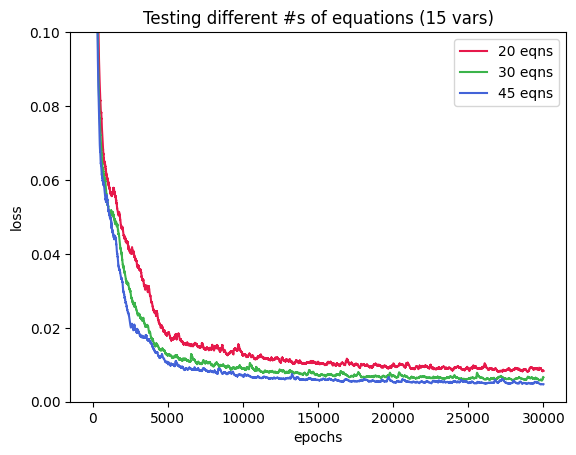

In [ ]:
plt.plot(avgs_20, label="20 eqns", color="#e6194B")
plt.plot(avgs_30, label="30 eqns", color="#3cb44b")
plt.plot(avgs_45, label="45 eqns", color="#4363d8")
plt.ylim(0, 0.1)
plt.title("Testing different #s of equations (15 vars)")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show();

In [ ]:
print('20 eqns:', avgs_20[-1] / ys.var().item())
print('30 eqns:', avgs_30[-1] / ys.var().item())
print('45 eqns:', avgs_45[-1] / ys.var().item())

20 eqns: 0.017238943958543085
30 eqns: 0.013514824405274984
45 eqns: 0.009741105870906298


In [ ]:
batch_size = 1024

In [ ]:
def get_data_v4(num_pairs, input_features=4):
  w1 = torch.randn(batch_size, input_features, 10) / (input_features ** 0.5)
  w2 = torch.randn(batch_size, 10, 1) / (10 ** 0.5)
  xs, ys = [], []
  for i in range(num_pairs):
    x = torch.randn(batch_size, input_features)
    y = batch_mlp(x, w1, w2)
    xs.append(x)
    ys.append(y)

  xs = torch.stack(xs, dim=1)
  ys = torch.stack(ys, dim=1)

  return xs, ys, w1, w2

xs, ys, w1, w2 = get_data_v4(num_pairs=100)
xs.shape, ys.shape, w1.shape, w2.shape

(torch.Size([1024, 100, 4]),
 torch.Size([1024, 100, 1]),
 torch.Size([1024, 4, 10]),
 torch.Size([1024, 10, 1]))

In [ ]:
print('67 eqns:', avgs_67[-1] / ys.var().item())
print('100 eqns:', avgs_100[-1] / ys.var().item())
print('150 eqns:', avgs_150[-1] / ys.var().item())

67 eqns: 0.08327848288366695
100 eqns: 0.06392254100826554
150 eqns: 0.061746966248031554


In [ ]:
def compute_weights_scaled(x, weights):
  B = weights.size(0)
  in_feat = x.size(-1)
  w1_flat, w2_flat = weights.split([in_feat*10, 10*1], dim=1)  # (B,40), (B,10)

  w1 = w1_flat.view(B, in_feat, 10)
  w2 = w2_flat.view(B, 10, 1)

  return batch_mlp(x, w1, w2)

In [ ]:
# define models
model_67 = WeightPredictor(x_dim=4, y_dim=1, out_dim=50, embed_dim=128)
model_100 = WeightPredictor(x_dim=4, y_dim=1, out_dim=50, embed_dim=128)
model_150 = WeightPredictor(x_dim=4, y_dim=1, out_dim=50, embed_dim=128)

# and execute!
avgs_67 = train_v2(model_67, lambda: get_data_v4(num_pairs=67), compute_weights_scaled, input_features=4, lr=1e-3, epochs=30000)
avgs_100 = train_v2(model_100, lambda: get_data_v4(num_pairs=100), compute_weights_scaled, input_features=4, lr=1e-3, epochs=30000)
avgs_150 = train_v2(model_150, lambda: get_data_v4(num_pairs=150), compute_weights_scaled, input_features=4, lr=1e-3, epochs=30000)

loss: 0.0303: 100%|██████████| 30000/30000 [23:14<00:00, 21.51it/s]


In [ ]:
# # to save all loss values to file
# import pickle

# group_avgs = [avgs_67, avgs_100, avgs_150]
# with open('/content/drive/MyDrive/dev-files/neuralpred/avgs_50u.pkl', 'wb') as f:
#   pickle.dump(group_avgs, f)

In [ ]:
# # if you need to load from a file
# group_avgs = []
# with open('/content/drive/MyDrive/dev-files/neuralpred/avgs_50u.pkl', 'rb') as f:
#   group_avgs = pickle.load(f)
# avgs_67, avgs_100, avgs_150 = group_avgs

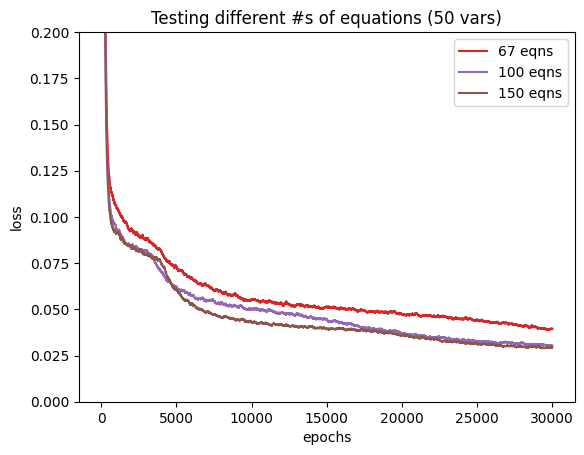

In [ ]:
plt.plot(avgs_67, label="67 eqns", color="#d62728")
plt.plot(avgs_100, label="100 eqns", color="#9467bd")
plt.plot(avgs_150, label="150 eqns", color="#8c564b")
plt.ylim(0, 0.2)
plt.title("Testing different #s of equations (50 vars)")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show();